# TEXBAT Feature Extraction — per-second windows

**Cel:** funkcja `extract_features(scenario)` → `DataFrame[t_int × features × label × phase]`, gotowa do trenowania XGBoost.

**Źródła feature'ów (per 1-second window):**
1. `channel.mat` — C/N0 stats, doppler/pseudorange spread, valid SV count, error flag
2. `iqtaps.mat` — **SQM features** z 41-tap correlator envelope (peak, asymmetry, secondary peak ratio, left/right means)
3. `cd1power*` / `tb*power*` `.mat` — wideband power AGC (2/4/8 MHz)
4. `navsol.mat` — clock error δR drift rate + position drift

**Etykieta** (binarna) i sub-faza (clean/inj/stealth/drift/walk):
- `cleanStatic`: label=0 (wszystko clean)
- `ds7`: label=0 dla t<110, label=1 dla t≥110, sub-fazy wg `texbat_ds7_and_ds8.pdf`
- `ds2`, `ds3`: label heuristic (label=1 dla t≥110, ale spoofing pattern może się różnić — używamy z ostrożnością)

**Output:** `data/features/{scenario}_features.parquet`.

In [1]:
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/texbat')
OUT  = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/features')
OUT.mkdir(parents=True, exist_ok=True)

# Phase definitions for ds7 (per texbat_ds7_and_ds8.pdf)
DS7_PHASES = [
    (0,   110, 'clean'),
    (110, 130, 'injection'),
    (130, 150, 'stealth'),
    (150, 400, 'drift'),
    (400, 468, 'walk'),
]

def assign_phase_ds7(t_int):
    return pd.cut(t_int, bins=[-1, 110, 130, 150, 400, 1e9],
                  labels=['clean','injection','stealth','drift','walk']).astype(str)

def assign_label(scenario, t_int):
    """Binary spoofing label per epoch. ds3/ds2 use heuristic onset at t=110 (paper-similar)."""
    if scenario == 'cleanStatic':
        return np.zeros(len(t_int), dtype=np.int8)
    if scenario in ('ds7', 'ds3', 'ds2'):
        return (t_int >= 110).astype(np.int8)
    raise ValueError(f'unknown scenario {scenario}')

print(f'DATA: {DATA.exists()},  OUT: {OUT}')

DATA: True,  OUT: /net/afscra/people/plgmateuszoracz/hackathon/data/features


## 1. `channel.mat` — C/N0 i pseudorange features

In [2]:
CHANNEL_COLS = ['rrt_wk','rrt_sow','ort_wk','ort_sow','ort_frac','doppler_hz',
                'carrier_phase','pseudorange_m','cn0_dbhz','valid_flag','error_flag',
                'channel_status','signal_type','txid']

def channel_features(scenario):
    arr = scipy.io.loadmat(DATA / scenario / 'channel.mat')['channel'].T
    df = pd.DataFrame(arr, columns=CHANNEL_COLS)
    df['t_rel'] = df['rrt_sow'] - df['rrt_sow'].iloc[0]
    df['t_int'] = df['t_rel'].astype(int)
    df['txid'] = df['txid'].astype(int)
    valid = df[df['valid_flag'] == 1]
    g = valid.groupby('t_int')
    feats = pd.DataFrame({
        'n_sv':         g['txid'].nunique(),
        'cn0_mean':     g['cn0_dbhz'].mean(),
        'cn0_std':      g['cn0_dbhz'].std(),
        'cn0_min':      g['cn0_dbhz'].min(),
        'cn0_max':      g['cn0_dbhz'].max(),
        'doppler_std':  g['doppler_hz'].std(),
        'pseudorange_std': g['pseudorange_m'].std(),
    })
    # Error flag aggregation (any flag set this second, any spoofing-bit-1 set)
    err_g = df.groupby('t_int')['error_flag']
    feats['error_flag_any']      = (err_g.max() > 0).astype(np.int8)
    feats['error_flag_spoofbit'] = (err_g.apply(lambda s: ((s.astype(int) & 0b10) > 0).any())).astype(np.int8)
    return feats

t0 = time.time()
ch_feats_clean = channel_features('cleanStatic')
print(f'cleanStatic channel features: {ch_feats_clean.shape} in {time.time()-t0:.2f}s')
ch_feats_clean.head()

cleanStatic channel features: (430, 9) in 0.11s


,n_sv,cn0_mean,cn0_std,cn0_min,cn0_max,doppler_std,pseudorange_std,error_flag_any,error_flag_spoofbit
t_int,,,,,,,,,
26,14,46.675840,5.180184,34.861649,52.191715,2005.719274,5.221979e+06,0,0
27,14,46.666074,5.176343,34.774620,52.209198,1995.943651,5.196702e+06,0,0
28,14,46.684875,5.145144,34.912270,52.208015,1995.826283,5.196715e+06,0,0
29,14,46.684852,5.139591,34.938324,52.196533,1995.806551,5.196728e+06,0,0
30,14,46.674554,5.146832,35.021271,52.179863,1995.740905,5.196741e+06,0,0


## 2. `iqtaps.mat` — **SQM features** (gold dla wykrywania spoofingu)

41 tapów I + 41 Q. Per-second per-SV uśredniamy envelope `√(I²+Q²)`, potem:
- `sqm_peak` — wartość przy argmax taps
- `sqm_asymmetry` — (right_5 − left_5) / (right_5 + left_5)
- `sqm_secondary_peak_ratio` — max envelope poza ±5 tapów / peak (klasyczna sygnatura podwójnego peaku przy code drift)
- `sqm_left_5_mean`, `sqm_right_5_mean` — średnie 5-tapowe okolice peaku

In [3]:
def iqtaps_features(scenario, n_taps=41, peak_window=5):
    arr = scipy.io.loadmat(DATA / scenario / 'iqtaps.mat')['iqtaps'].T
    rrt_sow = arr[:, 1]
    txid    = arr[:, 3].astype(int)
    t_rel   = rrt_sow - rrt_sow[0]
    t_int   = t_rel.astype(int)
    I = arr[:, 4:4+n_taps]
    Q = arr[:, 4+n_taps:4+2*n_taps]
    env = np.hypot(I, Q)  # (N, n_taps)

    keys = pd.DataFrame({'t_int': t_int, 'txid': txid})
    groups = keys.groupby(['t_int', 'txid']).indices  # dict (t,tx) -> indices array

    rec = np.empty(len(groups), dtype=[
        ('t_int','i4'),('txid','i4'),
        ('peak','f8'),('asym','f8'),('sec_peak_ratio','f8'),
        ('left_5_mean','f8'),('right_5_mean','f8'),
    ])
    tap_indices = np.arange(n_taps)
    for i, ((t_i, tx), idxs) in enumerate(groups.items()):
        avg_env = env[idxs].mean(axis=0)
        pi = int(avg_env.argmax())
        peak = avg_env[pi]
        l_lo, l_hi = max(0, pi - peak_window), pi
        r_lo, r_hi = pi + 1, min(n_taps, pi + 1 + peak_window)
        l5 = avg_env[l_lo:l_hi].mean() if l_hi > l_lo else np.nan
        r5 = avg_env[r_lo:r_hi].mean() if r_hi > r_lo else np.nan
        asym = (r5 - l5) / (r5 + l5 + 1e-12) if (r5+l5) > 0 else 0.0
        far_mask = np.abs(tap_indices - pi) > peak_window
        sec = avg_env[far_mask].max() / peak if peak > 0 and far_mask.any() else 0.0
        rec[i] = (t_i, tx, peak, asym, sec, l5, r5)

    sv_df = pd.DataFrame(rec)
    out = sv_df.groupby('t_int').agg(
        sqm_peak_mean=('peak','mean'),
        sqm_peak_std=('peak','std'),
        sqm_asym_mean=('asym','mean'),
        sqm_asym_max=('asym',lambda s: s.abs().max()),
        sqm_sec_peak_mean=('sec_peak_ratio','mean'),
        sqm_sec_peak_max=('sec_peak_ratio','max'),
        sqm_left_5_mean=('left_5_mean','mean'),
        sqm_right_5_mean=('right_5_mean','mean'),
    )
    return out

t0 = time.time()
iqt_feats_clean = iqtaps_features('cleanStatic')
print(f'cleanStatic iqtaps features: {iqt_feats_clean.shape} in {time.time()-t0:.1f}s')
iqt_feats_clean.head()

cleanStatic iqtaps features: (456, 8) in 5.0s


,sqm_peak_mean,sqm_peak_std,sqm_asym_mean,sqm_asym_max,sqm_sec_peak_mean,sqm_sec_peak_max,sqm_left_5_mean,sqm_right_5_mean
t_int,,,,,,,,
0,155567.063837,70066.016191,0.000544,0.013642,0.716678,0.739002,134139.395258,133971.388723
1,154483.616062,69637.845786,0.000089,0.010054,0.715770,0.736498,133081.482167,133141.487428
2,154290.240659,69686.891547,0.000623,0.011269,0.715883,0.736348,132794.093958,133052.685631
3,154479.023200,69197.207625,-0.000209,0.014962,0.715850,0.741365,133016.898234,133143.216042
4,154302.710588,68300.510775,-0.001192,0.018388,0.715198,0.749206,132948.971946,132905.879281


## 3. Wideband power AGC — `*power{2,4,8}MHz.mat`

Każdy scenariusz ma własny prefiks (cleanStatic→`cd1`, ds7→`tb7`, etc.) — używamy globa.
Sample rate w plikach to ~5 Hz (2280 próbek przez 460s) — uśredniamy do 1 Hz.

In [4]:
def power_features(scenario):
    out = None
    for mhz in (2, 4, 8):
        files = list((DATA / scenario).glob(f'*power{mhz}MHz.mat'))
        if not files:
            print(f'  WARN: no power{mhz}MHz file in {scenario}')
            continue
        d = scipy.io.loadmat(files[0])
        t = d['t'].flatten(); pw = d['power'].flatten()
        t_rel = t - t[0]
        df = pd.DataFrame({'t_int': t_rel.astype(int), f'power_{mhz}MHz': pw})
        agg = df.groupby('t_int')[f'power_{mhz}MHz'].mean().to_frame()
        out = agg if out is None else out.join(agg, how='outer')
    return out

t0 = time.time()
pw_feats_clean = power_features('cleanStatic')
print(f'cleanStatic power features: {pw_feats_clean.shape} in {time.time()-t0:.2f}s')
pw_feats_clean.head()

cleanStatic power features: (456, 3) in 0.02s


,power_2MHz,power_4MHz,power_8MHz
t_int,,,
0,59.801182,61.604119,63.765247
1,59.802028,61.603731,63.762874
2,59.808343,61.610168,63.771499
3,59.801988,61.614206,63.780501
4,59.784241,61.596499,63.764525


## 4. `navsol.mat` — clock error drift + position residuals

Per-second pochodne i drifty względem startu.

In [5]:
NAVSOL_COLS = ['ort_wk','ort_sow','ort_frac','X','Y','Z','deltR_m',
               'Xdot','Ydot','Zdot','deltRdot_mps','sol_flag']

def navsol_features(scenario):
    arr = scipy.io.loadmat(DATA / scenario / 'navsol.mat')['navsol'].T
    df = pd.DataFrame(arr, columns=NAVSOL_COLS)
    t = df['ort_sow'] + df['ort_frac']
    df['t_rel'] = t - t.iloc[0]
    df['t_int'] = df['t_rel'].astype(int)
    # Position drift from initial fix
    df['dx'] = df['X'] - df['X'].iloc[0]
    df['dy'] = df['Y'] - df['Y'].iloc[0]
    df['dz'] = df['Z'] - df['Z'].iloc[0]
    df['d_horiz'] = np.hypot(df['dx'], df['dy'])
    g = df.groupby('t_int')
    out = pd.DataFrame({
        'clock_error_m':       g['deltR_m'].mean(),
        'clock_drift_mps':     g['deltRdot_mps'].mean(),
        'position_drift_m':    g['d_horiz'].mean(),
        'speed_ecef':          g.apply(lambda gg: np.hypot(np.hypot(gg['Xdot'], gg['Ydot']), gg['Zdot']).mean()),
    })
    # Add second-derivative-like: rate of change of clock error
    out['clock_error_d_dt'] = out['clock_error_m'].diff().fillna(0)
    return out

t0 = time.time()
ns_feats_clean = navsol_features('cleanStatic')
print(f'cleanStatic navsol features: {ns_feats_clean.shape} in {time.time()-t0:.2f}s')
ns_feats_clean.head()

cleanStatic navsol features: (423, 5) in 0.14s


,clock_error_m,clock_drift_mps,position_drift_m,speed_ecef,clock_error_d_dt
t_int,,,,,
0,70815.888399,0.002313,21.544764,0.0,0.000000
1,70824.475617,0.000669,43.807271,0.0,8.587218
2,70826.679470,0.003107,49.681737,0.0,2.203853
3,70827.673395,0.006100,50.852132,0.0,0.993925
4,70827.826912,-0.001366,50.933698,0.0,0.153518


## 5. Pełny feature extractor — łączymy wszystko

In [6]:
def extract_features(scenario):
    t0 = time.time()
    print(f'[{scenario}] extracting...')
    ch  = channel_features(scenario);  print(f'  channel: {ch.shape}  ({time.time()-t0:.1f}s)')
    t1 = time.time()
    iqt = iqtaps_features(scenario);   print(f'  iqtaps:  {iqt.shape}  ({time.time()-t1:.1f}s)')
    t2 = time.time()
    pw  = power_features(scenario);    print(f'  power:   {pw.shape}   ({time.time()-t2:.1f}s)')
    t3 = time.time()
    ns  = navsol_features(scenario);   print(f'  navsol:  {ns.shape}   ({time.time()-t3:.1f}s)')
    
    df = ch.join(iqt, how='outer').join(pw, how='outer').join(ns, how='outer')
    df = df.sort_index().reset_index().rename(columns={'index':'t_int'})
    df['scenario'] = scenario
    df['label'] = assign_label(scenario, df['t_int'].values)
    if scenario == 'ds7':
        df['phase'] = assign_phase_ds7(df['t_int'].values)
    else:
        df['phase'] = 'clean' if scenario == 'cleanStatic' else 'unknown'
    print(f'  TOTAL: {df.shape} in {time.time()-t0:.1f}s')
    return df

feat_clean = extract_features('cleanStatic')
feat_clean.head()

[cleanStatic] extracting...


  channel: (430, 9)  (0.1s)


  iqtaps:  (456, 8)  (4.2s)
  power:   (456, 3)   (0.0s)


  navsol:  (423, 5)   (0.3s)
  TOTAL: (456, 29) in 4.6s


,t_int,n_sv,cn0_mean,cn0_std,cn0_min,cn0_max,doppler_std,pseudorange_std,error_flag_any,error_flag_spoofbit,...,power_4MHz,power_8MHz,clock_error_m,clock_drift_mps,position_drift_m,speed_ecef,clock_error_d_dt,scenario,label,phase
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.604119,63.765247,70815.888399,0.002313,21.544764,0.0,0.000000,cleanStatic,0,clean
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.603731,63.762874,70824.475617,0.000669,43.807271,0.0,8.587218,cleanStatic,0,clean
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.610168,63.771499,70826.679470,0.003107,49.681737,0.0,2.203853,cleanStatic,0,clean
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.614206,63.780501,70827.673395,0.006100,50.852132,0.0,0.993925,cleanStatic,0,clean
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.596499,63.764525,70827.826912,-0.001366,50.933698,0.0,0.153518,cleanStatic,0,clean


In [7]:
feat_ds7 = extract_features('ds7')
feat_ds3 = extract_features('ds3')
feat_ds2 = extract_features('ds2')

all_features = pd.concat([feat_clean, feat_ds7, feat_ds3, feat_ds2], ignore_index=True)
print(f'\nCombined: {all_features.shape}')
print(f'Per scenario:\n{all_features["scenario"].value_counts()}')
print(f'\nPer ds7 phase:\n{feat_ds7["phase"].value_counts()}')
print(f'\nLabel balance:\n{all_features["label"].value_counts()}')

[ds7] extracting...
  channel: (442, 9)  (0.1s)


  iqtaps:  (468, 8)  (4.2s)
  power:   (468, 3)   (0.0s)
  navsol:  (435, 5)   (0.1s)
  TOTAL: (468, 29) in 4.5s
[ds3] extracting...


  channel: (432, 9)  (0.1s)


  iqtaps:  (456, 8)  (4.2s)
  power:   (456, 3)   (0.0s)
  navsol:  (420, 5)   (0.2s)
  TOTAL: (456, 29) in 4.4s
[ds2] extracting...


  channel: (433, 9)  (0.1s)


  iqtaps:  (456, 8)  (4.4s)
  power:   (456, 3)   (0.0s)
  navsol:  (420, 5)   (0.1s)
  TOTAL: (456, 29) in 4.6s

Combined: (1836, 29)
Per scenario:
scenario
ds7            468
cleanStatic    456
ds3            456
ds2            456
Name: count, dtype: int64

Per ds7 phase:
phase
drift        250
clean        111
walk          67
injection     20
stealth       20
Name: count, dtype: int64

Label balance:
label
1    1050
0     786
Name: count, dtype: int64


## 6. Sanity check — porównanie rozkładów feature'ów

Dla każdego feature: histogram clean (cleanStatic) vs spoofed (ds7 t≥110). Powinniśmy zobaczyć separowalność dla najlepszych feature'ów (power_*MHz, sqm_*, clock_error_*).

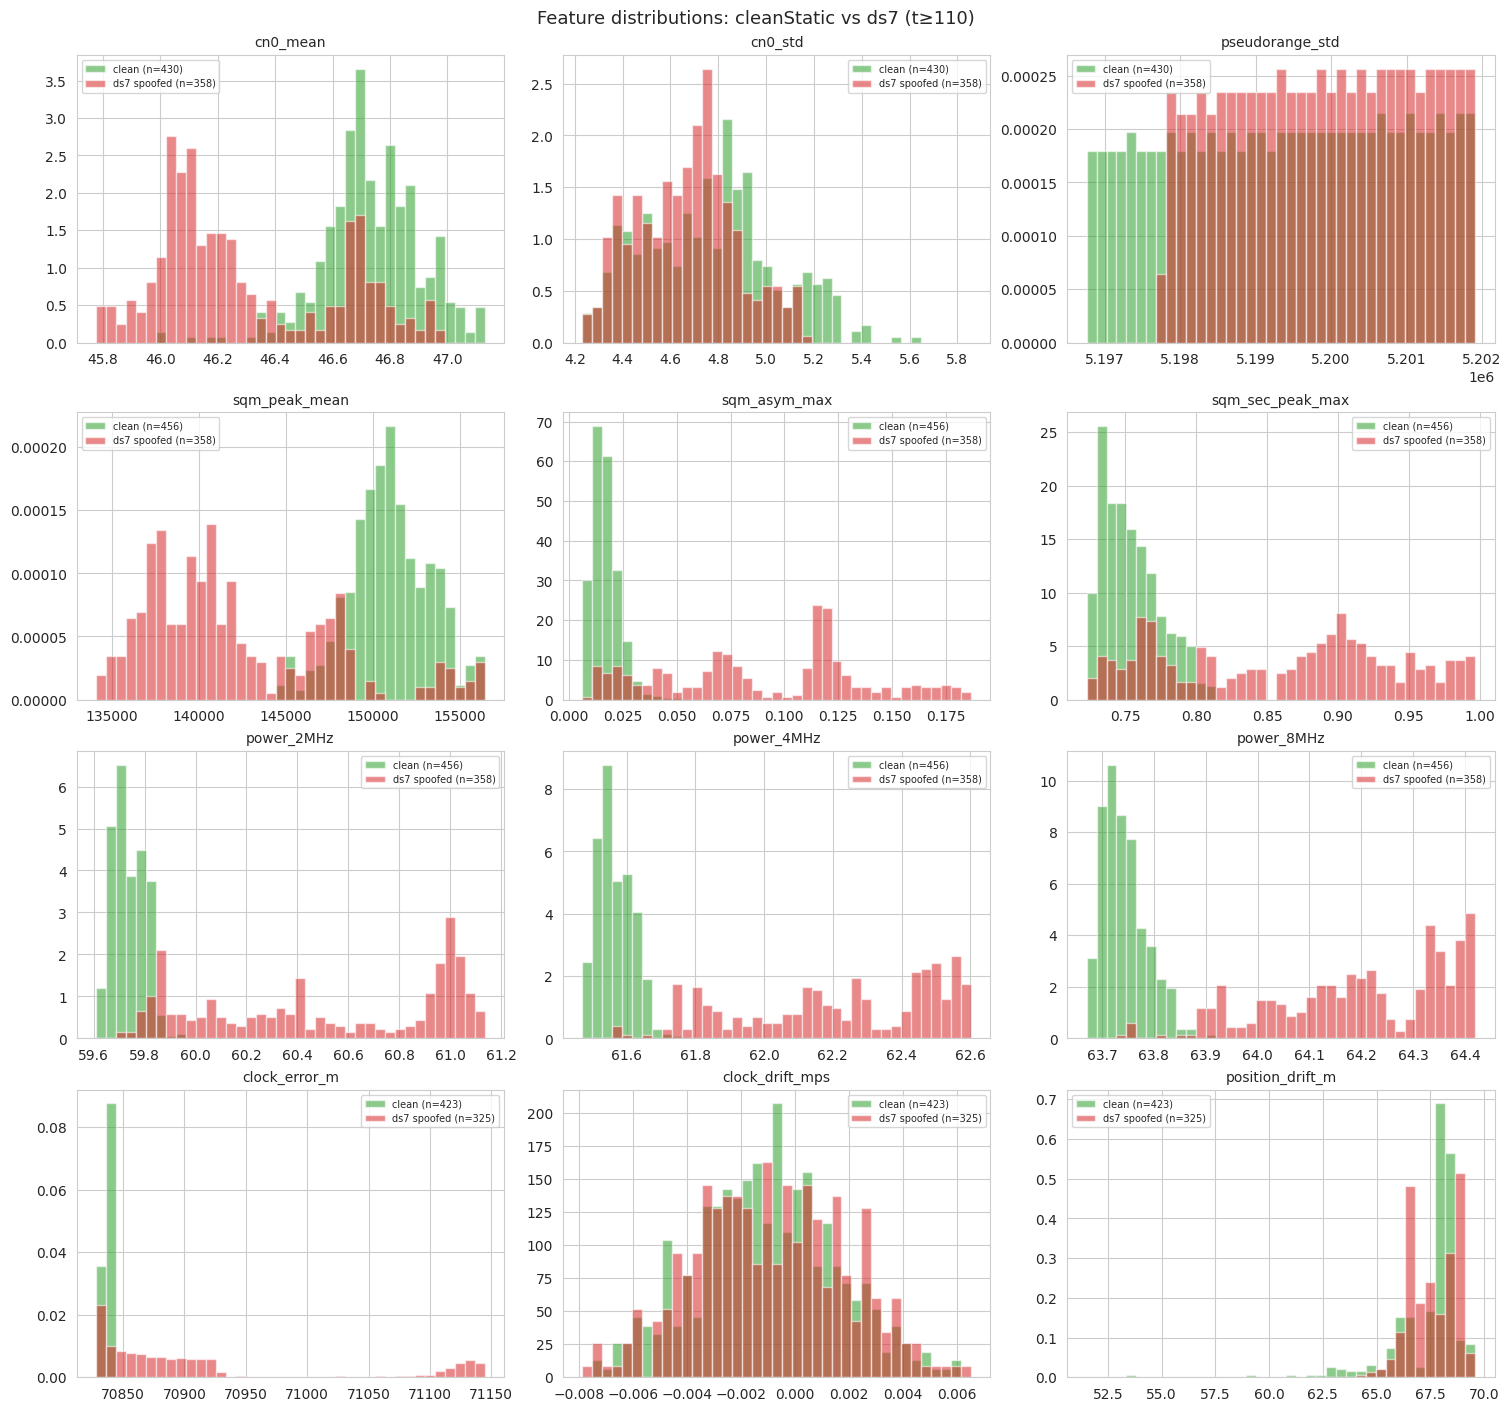

In [8]:
compare_feats = ['cn0_mean','cn0_std','pseudorange_std',
                 'sqm_peak_mean','sqm_asym_max','sqm_sec_peak_max',
                 'power_2MHz','power_4MHz','power_8MHz',
                 'clock_error_m','clock_drift_mps','position_drift_m']

clean_only = feat_clean.copy()
ds7_spoofed = feat_ds7[feat_ds7['t_int'] >= 110]

fig, axes = plt.subplots(4, 3, figsize=(15, 14), constrained_layout=True)
for ax, feat in zip(axes.flatten(), compare_feats):
    if feat not in feat_clean.columns:
        ax.set_visible(False); continue
    a = clean_only[feat].dropna()
    b = ds7_spoofed[feat].dropna()
    if len(a) and len(b):
        rng_lo = min(a.quantile(0.01), b.quantile(0.01))
        rng_hi = max(a.quantile(0.99), b.quantile(0.99))
        bins = np.linspace(rng_lo, rng_hi, 40)
        ax.hist(a, bins=bins, alpha=0.55, label=f'clean (n={len(a)})', color='tab:green', density=True)
        ax.hist(b, bins=bins, alpha=0.55, label=f'ds7 spoofed (n={len(b)})', color='tab:red', density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Feature distributions: cleanStatic vs ds7 (t≥110)', fontsize=13)
plt.show()

In [9]:
# Per-phase mean for ds7 — które feature'y najmocniej zmieniają się przez fazy?
phase_means = feat_ds7.groupby('phase')[compare_feats].mean().reindex(
    ['clean','injection','stealth','drift','walk'])
phase_means_clean = feat_clean[compare_feats].mean()
phase_means.loc['cleanStatic_baseline'] = phase_means_clean
phase_means.T  # wider readable form

phase,clean,injection,stealth,drift,walk,cleanStatic_baseline
cn0_mean,4.666601e+01,4.649378e+01,4.686148e+01,4.611902e+01,4.666752e+01,4.673803e+01
cn0_std,4.828958e+00,4.772071e+00,4.780124e+00,4.721036e+00,4.372942e+00,4.780625e+00
pseudorange_std,5.197532e+06,5.197913e+06,5.198170e+06,5.199779e+06,5.202098e+06,5.199514e+06
sqm_peak_mean,1.511075e+05,1.470530e+05,1.549077e+05,1.393769e+05,1.468454e+05,1.509606e+05
sqm_asym_max,1.932661e-02,3.293166e-02,2.937141e-02,1.099733e-01,5.759501e-02,1.688212e-02
sqm_sec_peak_max,7.641123e-01,7.948405e-01,7.397945e-01,8.512704e-01,9.500437e-01,7.540106e-01
power_2MHz,5.974220e+01,6.009336e+01,6.040468e+01,6.040543e+01,6.105153e+01,5.973641e+01
power_4MHz,6.157088e+01,6.188040e+01,6.215499e+01,6.216937e+01,6.255952e+01,6.156488e+01
power_8MHz,6.374992e+01,6.397583e+01,6.418725e+01,6.417432e+01,6.439157e+01,6.374208e+01
clock_error_m,7.083530e+04,7.083369e+04,7.083234e+04,7.090110e+04,7.113646e+04,7.083612e+04


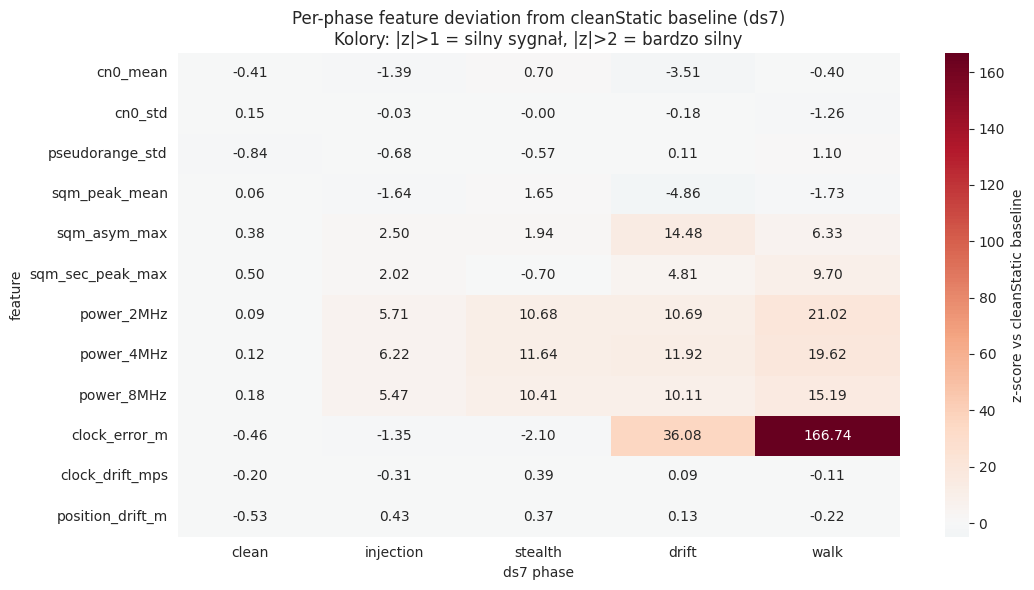

In [10]:
# Heatmap: per-phase mean (z-scored vs cleanStatic) — pokazuje co odróżnia każdą fazę spoofingu
from matplotlib.colors import TwoSlopeNorm

base_mean = feat_clean[compare_feats].mean()
base_std  = feat_clean[compare_feats].std().replace(0, 1)
phase_z = (phase_means.drop('cleanStatic_baseline') - base_mean) / base_std

fig, ax = plt.subplots(figsize=(11, 6))
norm = TwoSlopeNorm(vcenter=0)
sns.heatmap(phase_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'z-score vs cleanStatic baseline'}, ax=ax)
ax.set_title('Per-phase feature deviation from cleanStatic baseline (ds7)\nKolory: |z|>1 = silny sygnał, |z|>2 = bardzo silny')
ax.set_ylabel('feature'); ax.set_xlabel('ds7 phase')
plt.tight_layout(); plt.show()

## 7. Save to parquet

In [11]:
for s in ('cleanStatic', 'ds2', 'ds3', 'ds7'):
    df = all_features[all_features['scenario'] == s]
    p = OUT / f'{s}_features.parquet'
    df.to_parquet(p, index=False)
    print(f'  {p}: {df.shape} ({p.stat().st_size/1024:.1f} KB)')

p_all = OUT / 'all_features.parquet'
all_features.to_parquet(p_all, index=False)
print(f'\n  {p_all}: {all_features.shape} ({p_all.stat().st_size/1024:.1f} KB)')

  /net/afscra/people/plgmateuszoracz/hackathon/data/features/cleanStatic_features.parquet: (456, 29) (99.4 KB)
  /net/afscra/people/plgmateuszoracz/hackathon/data/features/ds2_features.parquet: (456, 29) (100.0 KB)
  /net/afscra/people/plgmateuszoracz/hackathon/data/features/ds3_features.parquet: (456, 29) (99.7 KB)
  /net/afscra/people/plgmateuszoracz/hackathon/data/features/ds7_features.parquet: (468, 29) (101.7 KB)

  /net/afscra/people/plgmateuszoracz/hackathon/data/features/all_features.parquet: (1836, 29) (340.2 KB)


## 8. Wnioski + co dalej

Mamy DataFrame z ~460 wierszy (s) × ~25 kolumn × 4 scenariusze. To wystarczy na pierwszy XGBoost.

**Następny notebook `03_baseline_xgboost.ipynb`:**
- Train: `cleanStatic` (label=0) + `ds3` (z `t<110` jako label=0, `t≥110` jako label=1)
- Test:  `ds7` — out-of-distribution scenariusz (nigdy nie widziany w treningu, najtrudniejszy)
- Metrics: F1, precision, recall + **per-phase F1** (clean/inj/stealth/drift/walk)
- SHAP TreeExplainer na top samplach
- Confusion matrix